In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anshtanwar/jellyfish-types")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'jellyfish-types' dataset.
Path to dataset files: /kaggle/input/jellyfish-types


Using Colab cache for faster access to the 'jellyfish-types' dataset.
Dataset Path: /kaggle/input/jellyfish-types
Total Images: 1879


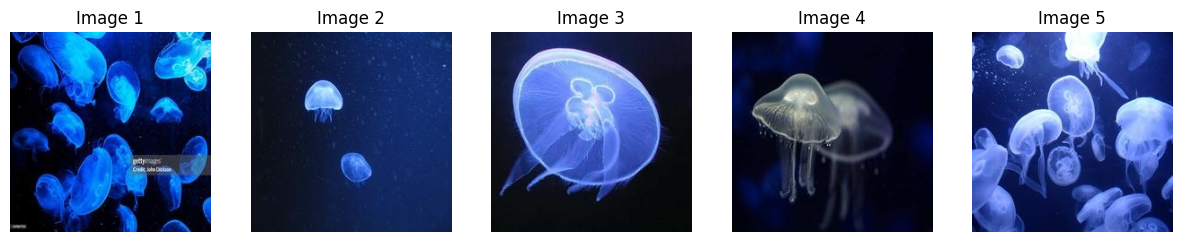

In [21]:
# ==========================
# 1. Import Libraries
# ==========================
import os
import cv2
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# 2. Download Dataset
# ==========================
path = kagglehub.dataset_download("anshtanwar/jellyfish-types")

print("Dataset Path:", path)

# ==========================
# 3. Collect Image Paths
# ==========================
image_paths = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(root, file))

print("Total Images:", len(image_paths))

# ==========================
# Question 1
# Load and Visualize 5 Images
# ==========================
plt.figure(figsize=(15,5))

for i in range(5):
    img = cv2.imread(image_paths[i])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [22]:
image_info = []

for img_path in image_paths:
    img = cv2.imread(img_path)

    if img is not None:
        h, w, c = img.shape

        image_info.append({
            "Image_Name": os.path.basename(img_path),
            "Height": h,
            "Width": w,
            "Channels": c
        })

df = pd.DataFrame(image_info)

print(df.head())

# Save table if needed
df.to_csv("image_dimensions.csv", index=False)

  Image_Name  Height  Width  Channels
0     20.jpg     224    224         3
1     60.jpg     224    224         3
2     44.jpg     224    224         3
3     09.jpg     224    224         3
4     15.jpg     224    224         3


Total resized images: 1879


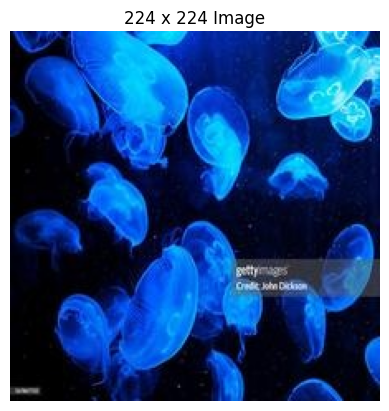

In [23]:
resized_images = []

for img_path in image_paths:
    img = cv2.imread(img_path)

    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

# Display one sample
plt.imshow(cv2.cvtColor(resized_images[0], cv2.COLOR_BGR2RGB))
plt.title("224 x 224 Image")
plt.axis("off")
plt.show()

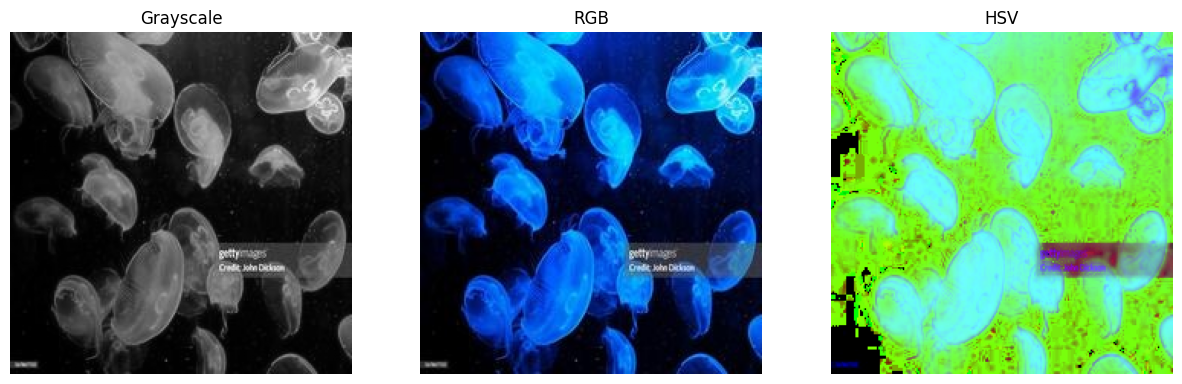

In [24]:
img = cv2.imread(image_paths[0])

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()

In [25]:
img = cv2.imread(image_paths[0])

normalized_img = img / 255.0

print("Before Normalization")
print("Min:", img.min(), "Max:", img.max())

print("\nAfter Normalization")
print("Min:", normalized_img.min(), "Max:", normalized_img.max())

Before Normalization
Min: 0 Max: 255

After Normalization
Min: 0.0 Max: 1.0


In [26]:
!pip install tensorflow

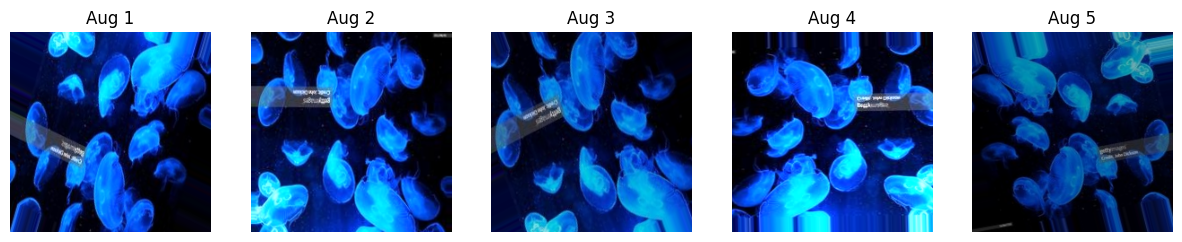

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread(image_paths[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to batch format
img = img.reshape((1,) + img.shape)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3]
)

# Generate augmented images
aug_iter = datagen.flow(img, batch_size=1)

plt.figure(figsize=(15,5))

for i in range(5):
    aug_img = next(aug_iter)[0].astype('uint8')

    plt.subplot(1,5,i+1)
    plt.imshow(aug_img)
    plt.axis("off")
    plt.title(f"Aug {i+1}")

plt.show()

In [28]:
import cv2
import numpy as np

def preprocess_image(image_path,
                     target_size=(224,224),
                     grayscale=False,
                     normalize=True,
                     gaussian_blur=False,
                     median_blur=False):

    # Read Image
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("Image not found!")

    # Resize
    img = cv2.resize(img, target_size)

    # Grayscale
    if grayscale:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur
    if gaussian_blur:
        img = cv2.GaussianBlur(img, (5,5), 0)

    # Median Blur
    if median_blur:
        img = cv2.medianBlur(img, 5)

    # Normalize
    if normalize:
        img = img / 255.0

    return img

array([[ 7, 17, 55, ..., 12, 27, 16],
       [ 8, 14, 42, ..., 15, 23, 20],
       [ 7, 10, 22, ..., 20, 18, 27],
       ...,
       [ 0,  1,  2, ...,  1,  3,  6],
       [ 4,  2,  3, ...,  1,  2,  4],
       [ 0,  0,  2, ...,  1,  0,  0]], dtype=uint8)
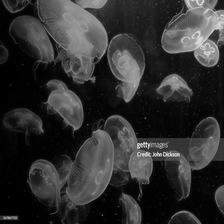

In [30]:
 preprocess_image(image_paths[0], grayscale=True, normalize=False)